## 1. Imports

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization libraries for EDA
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit for cheminformatics (SMILES → molecular features)
from rdkit.Chem import MolFromSmiles, Descriptors, Draw, AllChem

# Dimensionality reduction
from sklearn.decomposition import PCA

# Prevent large warning prints
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
df = pd.read_csv("../data/processed/mmp9_clean.csv")

## 2. Exploratory Data Analysis

Before cleaning, understand the dataset structure — number of columns, null values, data types.  
This informs which filters are necessary and how much data will be retained.

In [3]:
# Dataset dimensions
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (2397, 47)
Rows: 2397, Columns: 47


In [4]:
# Data types and null counts per column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2397 entries, 0 to 2396
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                196 non-null    object 
 1   activity_comment           53 non-null     object 
 2   activity_id                2397 non-null   int64  
 3   activity_properties        2397 non-null   object 
 4   assay_chembl_id            2397 non-null   object 
 5   assay_description          2397 non-null   object 
 6   assay_type                 2397 non-null   object 
 7   assay_variant_accession    16 non-null     object 
 8   assay_variant_mutation     16 non-null     object 
 9   bao_endpoint               2397 non-null   object 
 10  bao_format                 2397 non-null   object 
 11  bao_label                  2397 non-null   object 
 12  canonical_smiles           2397 non-null   object 
 13  data_validity_comment      0 non-null      float

In [5]:
# All column names for reference
df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value', 'bioactivity_class'],
      dtype='object')

## 3. pChEMBL Value Analysis

**pChEMBL = -log10(IC50 in molar)**  
ChEMBL standardizes all activity values to this scale — no manual unit conversion needed.  

**Threshold:** pChEMBL ≥ 5.4 = IC50 ≤ 5μM = **ACTIVE**  
**Rationale:** 5μM is a common threshold in QSAR literature for MMP inhibitors,  
representing therapeutic relevance while retaining sufficient data points.

In [6]:
# Check pChEMBL distribution
print("pChEMBL value statistics:")
print(df['pchembl_value'].describe())

pChEMBL value statistics:
count    2397.000000
mean        7.018865
std         1.496686
min         4.000000
25%         5.880000
50%         7.190000
75%         8.200000
max        11.000000
Name: pchembl_value, dtype: float64


In [7]:
# Convert pChEMBL to numeric — errors='coerce' converts non-numeric to NaN
df['pchembl_value'] = pd.to_numeric(df['pchembl_value'], errors='coerce')
print(f"Records with valid pChEMBL values: {df['pchembl_value'].notna().sum()}")
print(f"Records missing pChEMBL: {df['pchembl_value'].isna().sum()}")

Records with valid pChEMBL values: 2397
Records missing pChEMBL: 0


In [8]:
for threshold in [5.4, 6.0, 6.2, 6.5, 7.0]:
    active = (df['pchembl_value'] >= threshold).sum()
    inactive = (df['pchembl_value'] < threshold).sum()
    total = len(df)
    print(f"Threshold {threshold}: Active={active} ({active/total*100:.1f}%), Inactive={inactive} ({inactive/total*100:.1f}%)")

Threshold 5.4: Active=1959 (81.7%), Inactive=438 (18.3%)
Threshold 6.0: Active=1752 (73.1%), Inactive=645 (26.9%)
Threshold 6.2: Active=1643 (68.5%), Inactive=754 (31.5%)
Threshold 6.5: Active=1528 (63.7%), Inactive=869 (36.3%)
Threshold 7.0: Active=1318 (55.0%), Inactive=1079 (45.0%)


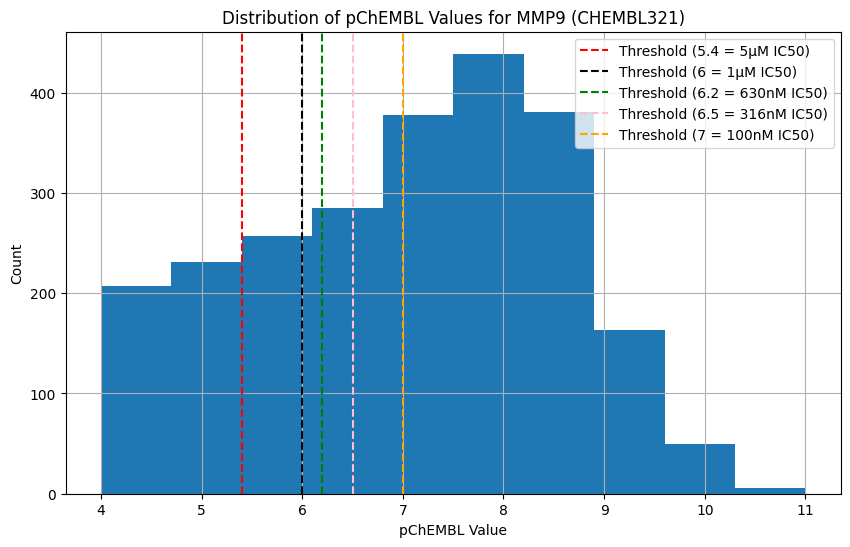

In [9]:
# Visualize pChEMBL distribution with activity threshold
df['pchembl_value'].hist(figsize=(10, 6))
plt.axvline(x=5.4, color='red', linestyle='--', label='Threshold (5.4 = 5μM IC50)')
plt.axvline(x=6, color='black', linestyle='--', label='Threshold (6 = 1μM IC50)')
plt.axvline(x=6.2, color='green', linestyle='--', label='Threshold (6.2 = 630nM IC50)')
plt.axvline(x=6.5, color='pink', linestyle='--', label='Threshold (6.5 = 316nM IC50)')
plt.axvline(x=7, color='orange', linestyle='--', label='Threshold (7 = 100nM IC50)')
plt.xlabel('pChEMBL Value')
plt.ylabel('Count')
plt.title('Distribution of pChEMBL Values for MMP9 (CHEMBL321)')
plt.legend()
plt.show()

## 4. Lipinski

Distribution of molecular descriptors:
- Molecular Weight
- LogP
- Hydrogen Bond Donors/Acceptors

In [10]:
def get_lipinski_data(smiles):

    mol = MolFromSmiles(smiles)
    if mol is None:
        return pd.Series([None]*4) # Return empty values if SMILES is invalid
    
    # Calculate the actual values
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    return pd.Series([mw, logp, hbd, hba])

# Create the new columns
props = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]
df[props] = df["canonical_smiles"].apply(get_lipinski_data)

# NOW you can filter the rows if you want to keep only Lipinski-compliant ones
before = len(df)
df = df[
    (df['MW'] <= 500) & 
    (df['LogP'] <= 5) & 
    (df['NumHDonors'] <= 5) & 
    (df['NumHAcceptors'] <= 10)
]

print(f"Lipinski filter: {before} → {len(df)} ({before - len(df)} removed)")

Lipinski filter: 2397 → 1661 (736 removed)


Lipinski descriptors show limited discriminative power between active and inactive MMP9 inhibitors, particularly LogP. This motivates the use of structural fingerprints for modeling.


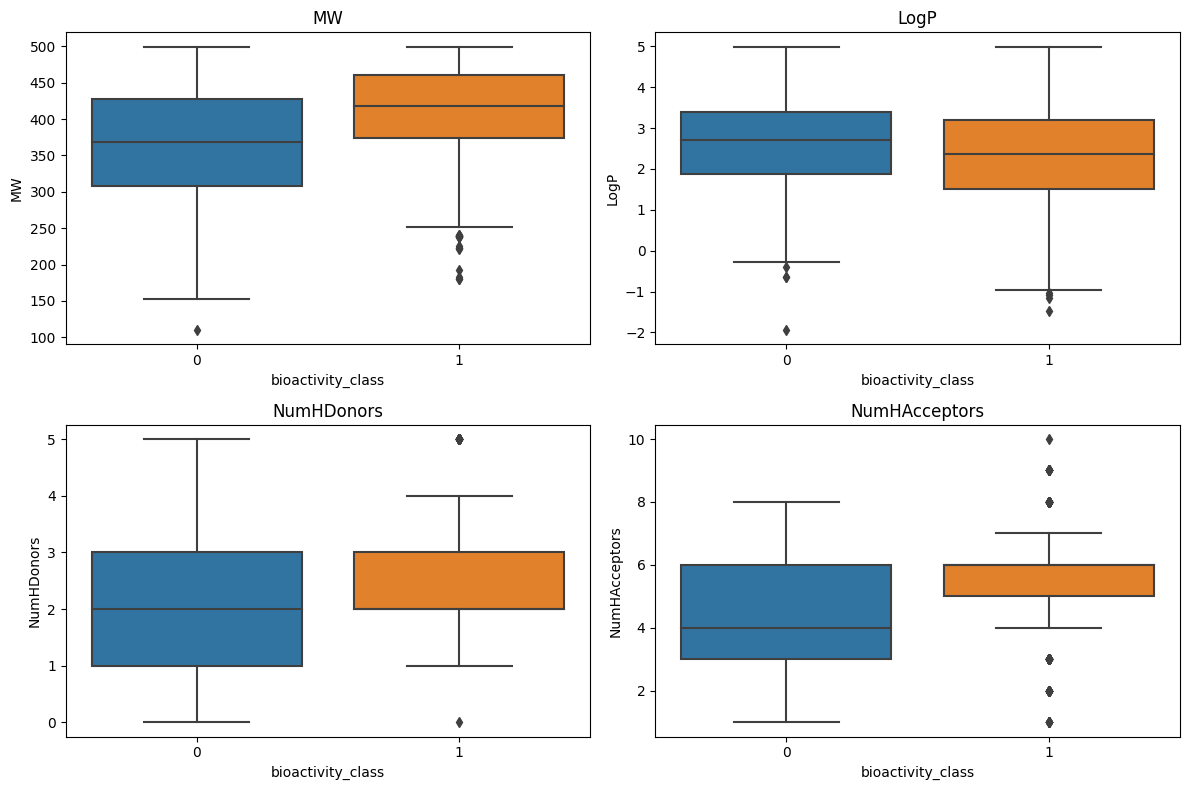

In [11]:
props = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# axes.flatten() gives us 4 individual plot areas
# props gives us 4 individual column names
for ax, prop in zip(axes.flatten(), props):
    # Use 'prop' (the current item in the loop), NOT 'props' (the whole list)
    sns.boxplot(data=df, x="bioactivity_class", y=prop, ax=ax) 
    ax.set_title(prop)

plt.tight_layout()
print("Lipinski descriptors show limited discriminative power between active and inactive MMP9 inhibitors, particularly LogP. This motivates the use of structural fingerprints for modeling.")

In [12]:
actives = df[df["bioactivity_class"] == 1]["canonical_smiles"].head(20)
inactives = df[df["bioactivity_class"] == 0]["canonical_smiles"].head(20)

active_mols = [MolFromSmiles(s) for s in actives]
inactive_mols = [MolFromSmiles(s) for s in inactives]

## 5. Visual Inspection of Molecules

We visualize sample active and inactive compounds
to qualitatively assess structural differences.

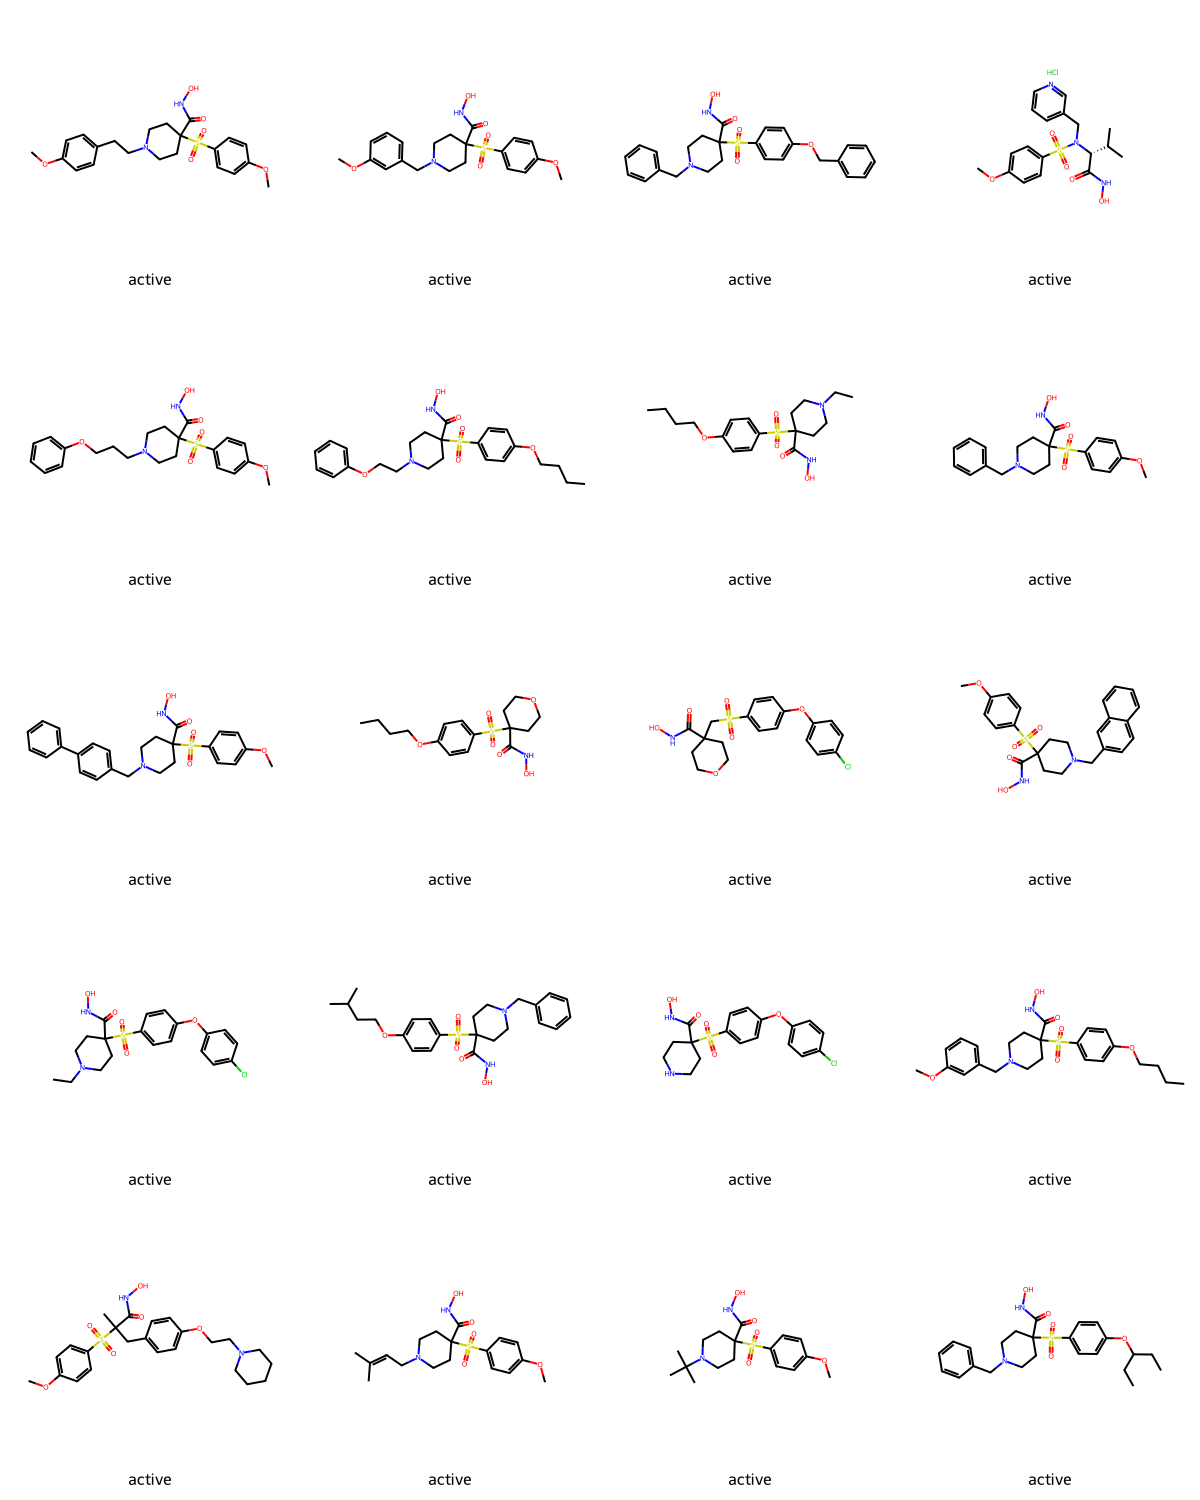

In [13]:
Draw.MolsToGridImage(active_mols, molsPerRow=4, subImgSize=(300,300), 
                     legends=["active"]*20)

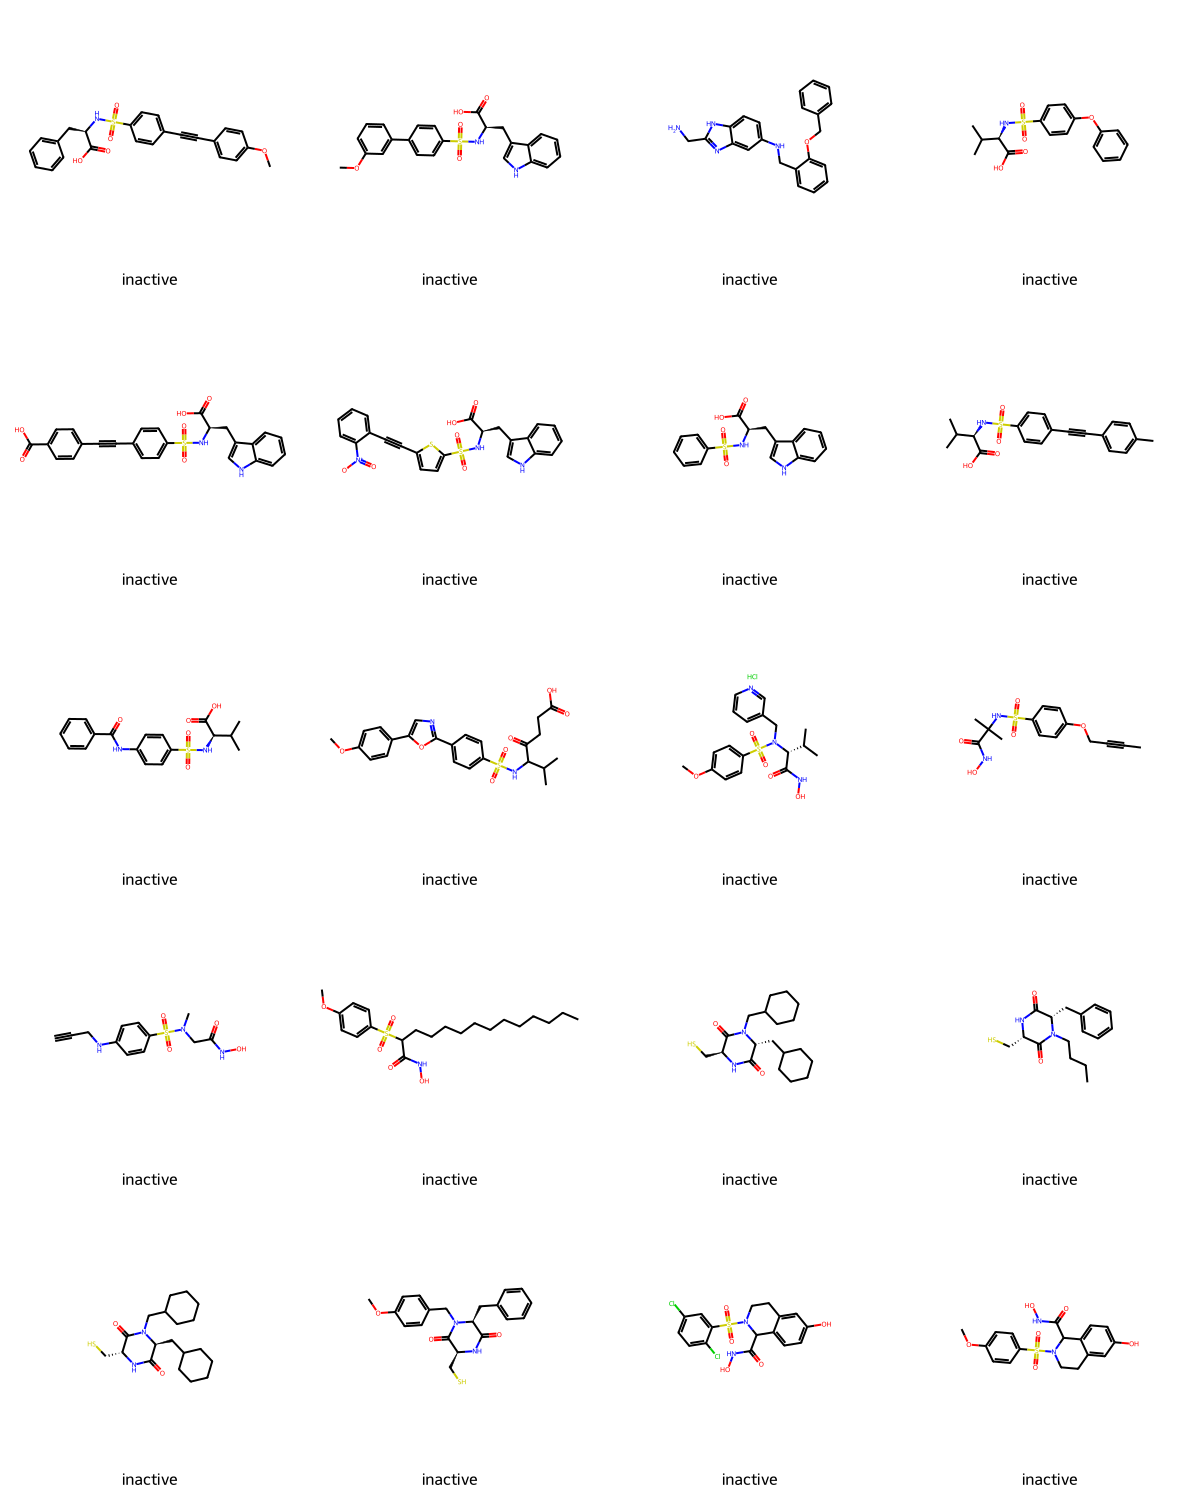

In [14]:
Draw.MolsToGridImage(inactive_mols, molsPerRow=4, subImgSize=(300,300), 
                     legends=["inactive"]*20)

## 6. Active vs Inactive

pchembl value distribution among active vs inactive compounds

c:\Users\LAPTOP LAB\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\LAPTOP LAB\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\LAPTOP LAB\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='pchembl_value', ylabel='Count'>

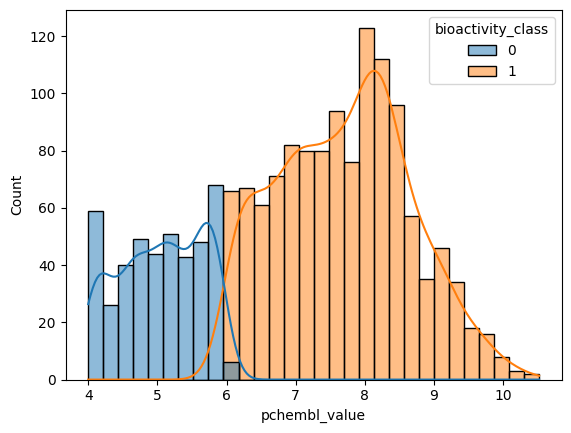

In [15]:
sns.histplot(data=df, x="pchembl_value", hue="bioactivity_class", 
             bins=30, kde=True)

## 7. Dimensionality Reduction

We apply PCA on molecular fingerprints to:
- Reduce dimensionality
- Visualize clustering of compounds

[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerator
[15:21:47] DEPRECATION WARNING: please use MorganGenerat

Text(0.5, 1.0, 'Chemical Space: MMP9 Inhibitors')

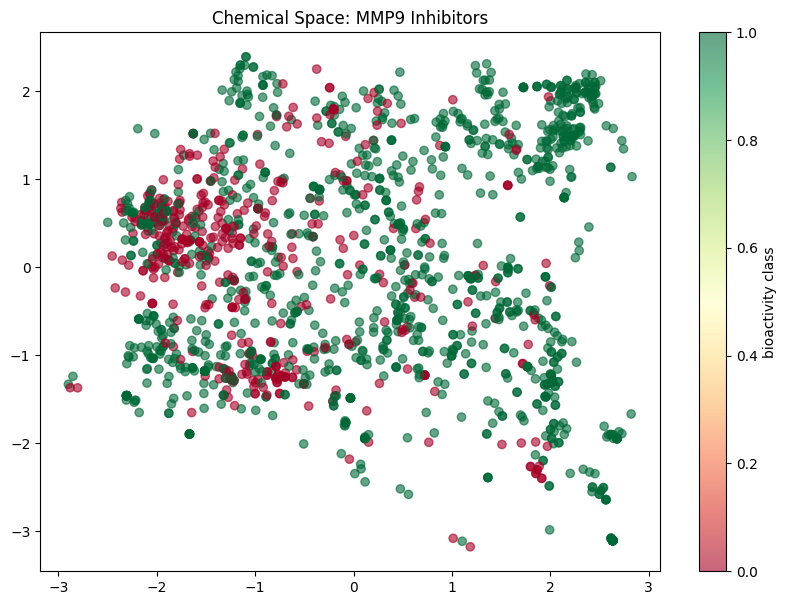

In [16]:
fps = df["canonical_smiles"].apply(
    lambda s: AllChem.GetMorganFingerprintAsBitVect(MolFromSmiles(s), 2, 2048)
)
X = np.array([list(fp) for fp in fps])

pca = PCA(n_components=2)
coords = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:,0], coords[:,1], 
                      c=df["bioactivity_class"], 
                      cmap="RdYlGn", alpha=0.6)
plt.colorbar(scatter, label="bioactivity class")
plt.title("Chemical Space: MMP9 Inhibitors")

In [17]:
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,type,units,uo_units,upper_value,value,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,NaN,NaN,33892,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,NaN,NaN,BAO_0000190,...,IC50,nM,UO_0000065,NaN,34.0,1,448.541,2.0602,2.0,7.0
1,NaN,NaN,35115,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,NaN,NaN,BAO_0000190,...,IC50,nM,UO_0000065,NaN,9.0,1,434.514,2.0177,2.0,7.0
3,NaN,NaN,35125,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,NaN,NaN,BAO_0000190,...,IC50,nM,UO_0000065,NaN,3.0,1,480.586,3.5795,2.0,6.0
4,NaN,NaN,35129,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,NaN,NaN,BAO_0000190,...,IC50,nM,UO_0000065,NaN,9.0,1,429.926,2.2329,2.0,6.0
5,NaN,NaN,37498,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,NaN,NaN,BAO_0000190,...,IC50,nM,UO_0000065,NaN,44.0,1,448.541,2.2780,2.0,7.0


## 8. Save Clean Dataset

Retain only the four columns required for downstream processing:
- `molecule_chembl_id` — unique compound identifier
- `canonical_smiles` — molecular structure (input for fingerprint generation)
- `pchembl_value` — raw activity value (useful for regression experiments later)
- `bioactivity_class` — binary label (0=inactive, 1=active) — model target


In [19]:
# Select final columns
df = df[[
    'molecule_chembl_id',
    'canonical_smiles',
    'pchembl_value',
    'bioactivity_class'
]]

# Save to processed data folder
output_path = '../data/processed/mmp9_processed.csv'
df.to_csv(output_path, index=False)

print(f"Clean dataset saved to: {output_path}")
print(f"Final shape: {df.shape}")
print(f"Active compounds: {df['bioactivity_class'].sum()}")
print(f"Inactive compounds: {(df['bioactivity_class']==0).sum()}")
print(f"Active compounds percentage: {(df['bioactivity_class'].value_counts(normalize=True)[1]*100):.2f}")
print(f"Inactive compounds percentage: {(df['bioactivity_class'].value_counts(normalize=True)[0]*100):.2f}")

Clean dataset saved to: ../data/processed/mmp9_processed.csv
Final shape: (1661, 4)
Active compounds: 1227
Inactive compounds: 434
Active compounds percentage: 73.87
Inactive compounds percentage: 26.13
